# **PROYECTO: INTRODUCCIÓN AL APRENDIZAJE AUTOMÁTICO**

Una vez visto el ***Módulo 5: Introducción al Aprendizaje Automático***, se presenta la siguiente actividad para que el alumnado pueda poner a prueba lo aprendido durante este módulo.

Dentro de la siguiente dinámica, realizar el siguiente **proyecto integrador**. En este proyecto se verá todo lo aprendido durante el **master en data science**.

Por lo que, el procedimiento a resolver es libre mientras se cumplan los puntos solicitados dentro de la descripción.

Puede descargar el conjunto de datos desde [aquí](https://docs.google.com/spreadsheets/d/1EvSrAe5JUoDUjU4x8Mm43q41Zecnov0wL4h8BbOT18M/edit?usp=drive_link).

## **ANÁLISIS DE TAMAÑO DE MERCADO DE VEHÍCULOS ELÉCTRICOS**

El análisis del tamaño del mercado es un aspecto crucial de la investigación de mercado que determina el volumen potencial de ventas dentro de un mercado determinado. Ayuda a las empresas a comprender la magnitud de la demanda, evaluar los niveles de saturación del mercado e identificar oportunidades de crecimiento. En este proyecto, Iicill lo llevará a través de la tarea de análisis de tamaño de mercado de Vehículos Eléctricos usando Python.

El análisis de tamaño de mercado para vehículos eléctricos implica un proceso de varios pasos que incluye definir el alcance del mercado, recopilar y preparar datos, modelar analíticamente y comunicar los hallazgos a través de visualización e informes. A continuación se muestra el proceso que puede seguir para la tarea de análisis de tamaño de mercado de vehículos eléctricos:

1.   Definir si el análisis es global, regional o centrado en países específicos.

2.   Recopilar información de asociaciones de la industria, empresas de investigación de mercado (por ejemplo, BloombergNEF, AIE) y publicaciones gubernamentales relevantes para el mercado de EV*.

3.   Utilice datos históricos para identificar tendencias en ventas, producción y mercado de EV*.

4.   Analice el tamaño del mercado y las tasas de crecimiento para diferentes segmentos de EV*.

5.   Según el análisis del tamaño del mercado, proporcione recomendaciones estratégicas para las empresas que buscan ingresar o expandirse en el mercado de EV* a través de predicciones.

_*NOTA: EV significa Electric Vehicles_

# **Vehiculos Eléctricos**

En esta investigación analizaremos los datos de vehículos eléctricos registrados por el Departamento de Licencias del Estado de Washington (DOL).

El dataset `Electric_Vehicle_Population_Data.csv` contiene 177,866 registros y 17 columnas, las cuales describiremos a continuación:  

---
***Identificación del vehículo***

---


    * VIN (1-10): Primeros 10 caracteres del Número de Identificación del Vehpiculo. No es el VIN completo por privacidad,   
    pero identifica de forma única la combinación de fabricante, modelo, año y planta.

    * DOL Vehicle ID: Identificador interno del Departamento de Licencias de Washington.

    * Model Year: Año modelo del vehículo (ej. 2022). Años que van de 1997 a 2024; 22 en total, los años no son consecutivos.

    * Make: Marca (Tesla, Nissan, Chevrolet, Ford, Kia, etc.), 40 marcas diferentes.

    * Model: Modelo específico (Model 3, Leaf, Bolt EV, Mustang Mach-E). 139 en total.
---
***Tipo y tecnología***

---

    * Electric Vehicle Type: Tipo de tecnología:
        - Battery Electric Vehicle (BEV), 100% eléctrico
        - Plug-in Hybrid Electric Vehicle (PHEV), híbrido enchufable.

    * Clean Alternative Fuel Vehicle (CAFV) Eligibility: Elegibilidad para incentivos estatales de Washington   
    (normalmente por precio o autonomía):
        - Clean Alternative Fuel Vehicle Eligible, elegible para exención de impuestos.
        - Not eligible, no califica.
        - Eligibility unknown, datos incompletos.

    * Electric Range: Autonomía eléctrica en millas según EPA.
        - Para BEV es rango total; de 250 a 350 mi
        - Para PHEV es rango en modo eléctrico; de 30 a 45 mi.

    * Base MSRP: Precio de venta base sugerido en USD.
---
***Ubicación geográfica y política***

---

    * County: Condado de registro (King, Snohomish, Pierce, etc.).

    * City: Ciudad de registro.

    * State: Estados de registro; 46 en total, aunque predomina "WA" en este dataset con un 99% de los datos.

    * Postal Code: Código postal de 5 dígitos.

    * Legislative District: Distrito legislativo de Washington (1-49).

    * Vehicle Location: Campo tipo POINT (lon lat). No es la dirección exacta por privacidad.

    * 2020 Census Tract: Código del tracto censal 2020 (11 dígitos).

    * Electric Utility: Compañía eléctrica que sirve esa dirección (ej. PUGET SOUND ENERGY INC, SEATTLE CITY LIGHT, TACOMA POWER).


---
## **Objetivos**


1. **Predicción de autonomía**: ¿Podemos predecir Electric Range con MAE <30 millas usando año, marca, modelo y tipo de vehículo para orientar incentivos 2026-2030 o demanda de BEV al 2026?
2. **Brecha geográfica**: ¿Qué condados presentan mayor desajuste adopción-infraestructura identificable por clustering en 2026?
3. **Diferencia BEV vs PHEV**: ¿Existe diferencia significativa (α=0.05) en rango entre BEV y PHEV?
4. **Probabilidad BEV**: ¿Cuál es la probabilidad de que un vehículo nuevo sea BEV según MSRP y año?
---

### **Análisis**

#### ***Reconocimiento de datos***

In [1]:
# Importamos librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import figure
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from scipy import stats


In [2]:
# Cargar Dataset

df_original = pd.read_csv('Electric_Vehicle_Population_Data.csv')
df_ev = df_original.copy()
df_ev.shape


(177866, 17)

In [3]:
# Reconocimiento

df_ev.info()
df_ev.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177866 entries, 0 to 177865
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         177866 non-null  object 
 1   County                                             177861 non-null  object 
 2   City                                               177861 non-null  object 
 3   State                                              177866 non-null  object 
 4   Postal Code                                        177861 non-null  float64
 5   Model Year                                         177866 non-null  int64  
 6   Make                                               177866 non-null  object 
 7   Model                                              177866 non-null  object 
 8   Electric Vehicle Type                              177866 non-null  object

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJYGDEE1L,King,Seattle,WA,98122.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291,0,37.0,125701579,POINT (-122.30839 47.610365),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
1,7SAYGDEE9P,Snohomish,Bothell,WA,98021.0,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,1.0,244285107,POINT (-122.179458 47.802589),PUGET SOUND ENERGY INC,5.306105e+10
2,5YJSA1E4XK,King,Seattle,WA,98109.0,2019,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,270,0,36.0,156773144,POINT (-122.34848 47.632405),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
3,5YJSA1E27G,King,Issaquah,WA,98027.0,2016,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,210,0,5.0,165103011,POINT (-122.03646 47.534065),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303303e+10
4,5YJYGDEE5M,Kitsap,Suquamish,WA,98392.0,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0,0,23.0,205138552,POINT (-122.55717 47.733415),PUGET SOUND ENERGY INC,5.303594e+10


In [4]:
# Validamos valores únicos

for col in df_ev.columns:
  print(f"Count: {df_ev[col].nunique()} \n{col}: {df_ev[col].unique()}")
  print("-"*200)
  print()


Count: 10830 
VIN (1-10): ['5YJYGDEE1L' '7SAYGDEE9P' '5YJSA1E4XK' ... 'YV4BR00Z6N' '1C4RJYE62P'
 'WMEFK9BA7J']
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Count: 196 
County: ['King' 'Snohomish' 'Kitsap' 'Thurston' 'Yakima' 'Island' 'Chelan'
 'Skagit' 'Spokane' 'Walla Walla' 'Grant' 'Stevens' 'Whitman' 'Kittitas'
 'Pend Oreille' 'Clark' 'Cowlitz' 'Jefferson' 'Clallam' 'Klickitat'
 'Pierce' 'Grays Harbor' 'Whatcom' 'Skamania' 'Wahkiakum' 'Washoe'
 'Benton' 'Franklin' 'Lewis' 'San Juan' 'Mason' 'Okanogan' 'Douglas'
 'Adams' 'Pacific' 'Asotin' 'District of Columbia' 'Columbia' 'Lincoln'
 'Kern' 'Cumberland' 'Oldham' 'Orange' 'Stafford' 'Montgomery' 'York'
 'Sonoma' 'San Diego' 'Marin' 'Ferry' 'Santa Clara' 'Contra Costa' 'Lake'
 "St. Mary's" 'Nueces' 'Platte' 'Los Angeles' 'DeKalb' 'Lee' 'Bexar'
 'Fairfax' 'Anne Arundel' 'Madison' 'S

In [5]:
# Copiar df con reconocimiento, previo a limpieza.

df_ev_rec = df_ev.copy()

#### ***Limpieza de datos***

In [6]:
# validación de nulos
print("\nValores nulos\n",
      df_ev_rec.isnull().sum().sort_values(ascending=False).head(10))

# validación de ceros
print("\nValores ceros\n",
      df_ev_rec.isin([0]).sum().sort_values(ascending=False).head(10))

# validación de duplicados
print("\nDuplicados:", df_ev_rec.duplicated().sum())



Valores nulos
 Legislative District     389
Vehicle Location           9
2020 Census Tract          5
County                     5
City                       5
Postal Code                5
Electric Utility           5
VIN (1-10)                 0
State                      0
Electric Vehicle Type      0
dtype: int64

Valores ceros
 Base MSRP                174522
Electric Range            91950
VIN (1-10)                    0
County                        0
City                          0
Model Year                    0
Make                          0
State                         0
Postal Code                   0
Electric Vehicle Type         0
dtype: int64

Duplicados: 0


##### **Imputación de datos**
* Se procede a eliminar 9 filas sin datos geográficos (County, City, Postal Code, Vehicle Location, 2020 Census Track y Electric Utility) para ahorrar recursos, ya que sólo representan el 0.00005% del dataset.  
* Así mismo, se imputa la columna Base MSRP con la mediana general. Pues aún cuando los datos en ceros son más del 98%, los 3mil registros con datos constituyen un buen conjunto para análisis. Esto deribado de que, para imputar basado en grupos característicos como Make o Model, no elimina los valores en ceros. Debemos considerar que, con esta medida, los resultados pueden estar sesgados; sin embargo, la media nos da una taza real de precios que podrían predominar el mercado.
* De igual manera con la columna Electric Range, se imputará a travez de la mediana de su grupo de tipo de vehículo.
* Por otro lado, Vehicle Location se parseará, haciendo de este dato 2 columnas (longitud y latitud) para uso posterior en mapas.
* Por útimo, se imputará Legislative District por medio de la mediana general, por la misma razón de que los datos del grupo geográfico City, County y Postal Code no eliminan los nulos.

In [7]:
# Imputación de nulos

# eliminar filas donde 2020 Census Tract = null
df_ev_rec = df_ev_rec.dropna(subset=['2020 Census Tract'])
df_ev_rec = df_ev_rec.dropna(subset=['Vehicle Location'])

# Base MSRP 0 -> NaN e imputación por mediana
df_ev_rec['Base MSRP'] = df_ev_rec['Base MSRP'].replace(0, np.nan)
df_ev_rec['Base MSRP'] = df_ev_rec['Base MSRP'].transform(lambda x:
                                                          x.fillna(x.median()))

# Electric Range 0 -> NaN y imputación por mediana
df_ev_rec['Electric Range'] = df_ev_rec['Electric Range'].replace(0, np.nan)
df_ev_rec['Electric Range'] = df_ev_rec.groupby('Electric Vehicle Type')['Electric Range'].transform(lambda x: x.fillna(x.median()))

# Legislative District 0 -> NaN e imputación por mediana
df_ev_rec['Legislative District'] = df_ev_rec['Legislative District'].replace(0, np.nan)
df_ev_rec['Legislative District'] = df_ev_rec['Legislative District'].transform(lambda x: x.fillna(x.median()))

# Vehicle Location parsear
df_ev_rec[['Lon','Lat']] = df_ev_rec['Vehicle Location'].str.extract(r'POINT \((.*) (.*)\)').astype(float)

# validación de nulos
print("\nValores nulos\n", df_ev_rec.isnull().sum().sort_values(ascending=False).head(10))

# validación de ceros
print("\nValores ceros\n", df_ev_rec.isin([0]).sum().sort_values(ascending=False).head(10))



Valores nulos
 VIN (1-10)                                           0
County                                               0
City                                                 0
State                                                0
Postal Code                                          0
Model Year                                           0
Make                                                 0
Model                                                0
Electric Vehicle Type                                0
Clean Alternative Fuel Vehicle (CAFV) Eligibility    0
dtype: int64

Valores ceros
 VIN (1-10)                                           0
County                                               0
City                                                 0
State                                                0
Postal Code                                          0
Model Year                                           0
Make                                                 0
Model               

In [8]:
# Cambiamos tipos de datos

cols_int = ['Postal Code', 'Electric Range', 'Base MSRP', 'Legislative District', '2020 Census Tract']
cols_cat = df_ev_rec.select_dtypes(include='object').columns


# Convertimos columnas float a tipo de dato int
df_ev_rec[cols_int] = df_ev_rec[cols_int].astype('int64')

# Convertimos columnas object a tipo de dato category
df_ev_rec[cols_cat] = df_ev_rec[cols_cat].astype('category')

df_ev_rec.info()


<class 'pandas.core.frame.DataFrame'>
Index: 177857 entries, 0 to 177865
Data columns (total 19 columns):
 #   Column                                             Non-Null Count   Dtype   
---  ------                                             --------------   -----   
 0   VIN (1-10)                                         177857 non-null  category
 1   County                                             177857 non-null  category
 2   City                                               177857 non-null  category
 3   State                                              177857 non-null  category
 4   Postal Code                                        177857 non-null  int64   
 5   Model Year                                         177857 non-null  int64   
 6   Make                                               177857 non-null  category
 7   Model                                              177857 non-null  category
 8   Electric Vehicle Type                              177857 non-null  c

In [9]:
# copiamos df_ev_rec para usar df limpio

df_ev_clean = df_ev_rec.copy()
df_ev_clean.head()


,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract,Lon,Lat
0,5YJYGDEE1L,King,Seattle,WA,98122,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291,59900,37,125701579,POINT (-122.30839 47.610365),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),53033007800,-122.308390,47.610365
1,7SAYGDEE9P,Snohomish,Bothell,WA,98021,2023,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,215,59900,1,244285107,POINT (-122.179458 47.802589),PUGET SOUND ENERGY INC,53061051938,-122.179458,47.802589
2,5YJSA1E4XK,King,Seattle,WA,98109,2019,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,270,59900,36,156773144,POINT (-122.34848 47.632405),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),53033006800,-122.348480,47.632405
3,5YJSA1E27G,King,Issaquah,WA,98027,2016,TESLA,MODEL S,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,210,59900,5,165103011,POINT (-122.03646 47.534065),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),53033032104,-122.036460,47.534065
4,5YJYGDEE5M,Kitsap,Suquamish,WA,98392,2021,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,215,59900,23,205138552,POINT (-122.55717 47.733415),PUGET SOUND ENERGY INC,53035940100,-122.557170,47.733415


#### ***EDA***

In [10]:
# Resumen Estadístico de variables numéricas

df_ev_clean.describe()


,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract,Lon,Lat
count,177857.000000,177857.000000,177857.000000,177857.000000,177857.000000,1.778570e+05,1.778570e+05,177857.000000,177857.000000
mean,98172.443126,2020.515684,169.990599,59846.726977,29.136070,2.202312e+08,5.297672e+10,-122.030845,47.442058
std,2442.477153,2.989208,83.205276,3147.287502,14.877259,7.584843e+07,1.578064e+09,1.811039,0.821664
min,1545.000000,1997.000000,6.000000,31950.000000,1.000000,4.385000e+03,1.001020e+09,-159.712480,19.610210
25%,98052.000000,2019.000000,84.000000,59900.000000,18.000000,1.814762e+08,5.303301e+10,-122.394185,47.357985
50%,98122.000000,2022.000000,215.000000,59900.000000,33.000000,2.282526e+08,5.303303e+10,-122.291790,47.610365
75%,98370.000000,2023.000000,215.000000,59900.000000,42.000000,2.548448e+08,5.305307e+10,-122.151665,47.715580
max,99577.000000,2024.000000,337.000000,845000.000000,49.000000,4.792548e+08,5.603300e+10,-70.873801,61.323155


In [11]:
# Resumen Estadístico de variables categóricas

df_ev_clean.describe(include='category')

# columna top
resumen_estadistico = df_ev_clean.describe(include='category').loc['top']
resumen_estadistico

,top
VIN (1-10),7SAYGDEE6P
County,King
City,Seattle
State,WA
Make,TESLA
Model,MODEL Y
Electric Vehicle Type,Battery Electric Vehicle (BEV)
Clean Alternative Fuel Vehicle (CAFV) Eligibility,Eligibility unknown as battery range has not b...
Vehicle Location,POINT (-122.12302 47.67668)
Electric Utility,PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)


In [12]:
# Gráficas Top

# Gráfica 1: Tipos de vehículos
fig_hist = px.histogram(df_ev_clean, x='Electric Vehicle Type',
                        color='Electric Vehicle Type',
                        title='BEV vs PHEV - BEV domina el mercado en un ~78%')
fig_hist.update_layout(showlegend=False)
fig_hist.show()

# guardamos hitograma en un archivo html
fig_hist.write_html('Tipos de vehículos.html')

#-------------------------------------------------------------------------------

# Gráfica 2: Marcas
top_Make = df_ev_clean['Make'].value_counts().head(8).reset_index()
fig_bar = px.bar(top_Make, x='Make', y='count',
                 title='Top marcas - Tesla lidera con ~42%')
fig_bar.update_layout(showlegend=False)
fig_bar.show()

# guardamos gráfica de barras en un archivo html
fig_bar.write_html('Top marcas.html')

#-------------------------------------------------------------------------------

# Gráfica 3: Precios (años)
by_msrp_e = df_ev_clean.groupby(['Base MSRP','Electric Vehicle Type'],
                                observed=False).size().reset_index(name='count')
fig_line = px.line(by_msrp_e, x='Base MSRP', y='count',
                   color='Electric Vehicle Type',
                   markers=True,
                   title='Precios estandar de ~60milUSD.')
fig_line.update_layout(showlegend=True, legend=dict(x=0, y=1,
                                                    xanchor='left',
                                                    yanchor='top'))
fig_line.show()

# guardamos gráfica en un archivo html
fig_line.write_html('Precios_EVT.html')

#-------------------------------------------------------------------------------

# Gráfica 4: Autonomía
by_er = df_ev_clean.groupby(['Electric Range','Electric Vehicle Type'],
                            observed=False).size().reset_index(name='count')
fig_line = px.line(by_er, x='Electric Range', y='count',
                   color='Electric Vehicle Type',
                   markers=True,
                   title='Autonomía eléctrica en millas según EPA - Los BEV presentan 10 veces más rendimiento.')
fig_line.update_layout(showlegend=True, legend=dict(x=0, y=1,
                                                    xanchor='left',
                                                    yanchor='top'))
fig_line.show()

# guardamos gráfica en un archivo html
fig_line.write_html('Autonomía.html')

#-------------------------------------------------------------------------------

# Gráfica 5: Eligibilidad
fig_hist = px.histogram(df_ev_clean, x='Clean Alternative Fuel Vehicle (CAFV) Eligibility',
                        color='Clean Alternative Fuel Vehicle (CAFV) Eligibility',
                        title='Elegibilidad para incentivos estatales WA - más del 37% son elegibles')
fig_hist.update_layout(showlegend=False)
fig_hist.show()

# guardamos hitograma en un archivo html
fig_hist.write_html('Elegibilidad para incentivos del gobierno.html')

Output hidden; open in https://colab.research.google.com to view.

In [13]:
# Animación de tipos de vehículos

import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import pandas as pd

by_year = df_ev_clean.groupby(['Model Year', 'Electric Vehicle Type'],
                              observed=False).size().reset_index(name='count')
model_years = sorted(by_year['Model Year'].unique())

fig, ax = plt.subplots(figsize=(12, 7))
ax.set_title('Adquisición anual de Vehículos Eléctricos por Tipo')
ax.set_xlabel('Año del Modelo')
ax.set_ylabel('Vehículos Adquiridos')

line_bev, = ax.plot([], [], label='Battery Electric Vehicle (BEV)',
                    marker='o', color='blue')
line_phev, = ax.plot([], [], label='Plug-in Hybrid Electric Vehicle (PHEV)',
                     marker='o', color='red')

ax.legend(loc='upper left')

ax.set_xlim(min(model_years) - 1, max(model_years) + 1)
ax.set_ylim(0, by_year['count'].max() * 1.1)

# Animación
def init():
    line_bev.set_data([], [])
    line_phev.set_data([], [])
    return line_bev, line_phev,

# Actualiza frame
def update(frame):
    current_year = model_years[frame]
    filtered_by_year = by_year[by_year['Model Year'] <= current_year]

    data_bev = filtered_by_year[filtered_by_year['Electric Vehicle Type'] == 'Battery Electric Vehicle (BEV)']
    data_phev = filtered_by_year[filtered_by_year['Electric Vehicle Type'] == 'Plug-in Hybrid Electric Vehicle (PHEV)']

    line_bev.set_data(data_bev['Model Year'], data_bev['count'])
    line_phev.set_data(data_phev['Model Year'], data_phev['count'])

    ax.set_title(f'Adquisición anual de EVT, evolución acelerada ({current_year})')

    return line_bev, line_phev,

animation_speed_ms = 500 # milisegundos por frame para mejor visualización
anim = animation.FuncAnimation(fig, update, frames=len(model_years),
                               init_func=init, blit=True,
                               interval=animation_speed_ms)

plt.close(fig)

# Display de animación
display(HTML(anim.to_jshtml()))

# Guardamos animación en archivo html
with open('Adquisicion_anual_animada.html', 'w') as f:
    f.write(anim.to_jshtml())


##### **Correlaciones Numéricas**

In [14]:
# correlaciones numéricas

numeric_cols = ['Model Year', 'Electric Range', 'Base MSRP', 'Legislative District']

# Figura con 4 subplots
fig_combin_box = make_subplots(rows=2, cols=2,
                                 subplot_titles=[f'Box Plot de {col}' for col in numeric_cols])
row_idx = 1
col_idx = 1
for col in numeric_cols:
    if (row_idx - 1) * 2 + (col_idx - 1) >= 4:
        break
    fig_combin_box.add_trace(go.Box(y=df_ev_clean[col], name=col),
                                 row=row_idx, col=col_idx)
    col_idx += 1
    if col_idx > 2:
        col_idx = 1
        row_idx += 1

fig_combin_box.update_layout(title_text='Box Plots de variables Numéricas',
                             title_x=0.5, height=1200, width=1200)
fig_combin_box.update_layout(showlegend=False)
fig_combin_box.show()

Output hidden; open in https://colab.research.google.com to view.

##### **Outliers (filtrado por IQR)**

In [15]:
# Filtramos outliers por medio de IQR

numeric_cols = ['Model Year', 'Electric Range', 'Base MSRP', 'Legislative District']

fig_combin_box_no_outliers = make_subplots(rows=2, cols=2,
                                         subplot_titles=[f'Box Plot de {col} (sin outliers)' for col in numeric_cols])

row_idx = 1
col_idx = 1

for col in numeric_cols:
    # Ccalculamos IQR
    Q1 = df_ev_clean[col].quantile(0.25)
    Q3 = df_ev_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    bajo = Q1 - 1.5 * IQR
    alto = Q3 + 1.5 * IQR

    df_filtered_col = df_ev_clean[(df_ev_clean[col] >= bajo) & (df_ev_clean[col] <= alto)]

    fig_combin_box_no_outliers.add_trace(go.Box(y=df_filtered_col[col], name=col,
                                                ),
                                         row=row_idx, col=col_idx)
    col_idx += 1
    if col_idx > 2:
        col_idx = 1
        row_idx += 1

fig_combin_box_no_outliers.update_layout(title_text='Box Plots de Variables Numéricas (Sin Outliers - IQR)',
                                        title_x=0.5, height=1200, width=1200)
fig_combin_box_no_outliers.update_layout(showlegend=False)
fig_combin_box_no_outliers.show()

# Guardamos boxplot en archivo html
fig_combin_box_no_outliers.write_html('Box_Plots_Num_IQR.html')


Output hidden; open in https://colab.research.google.com to view.

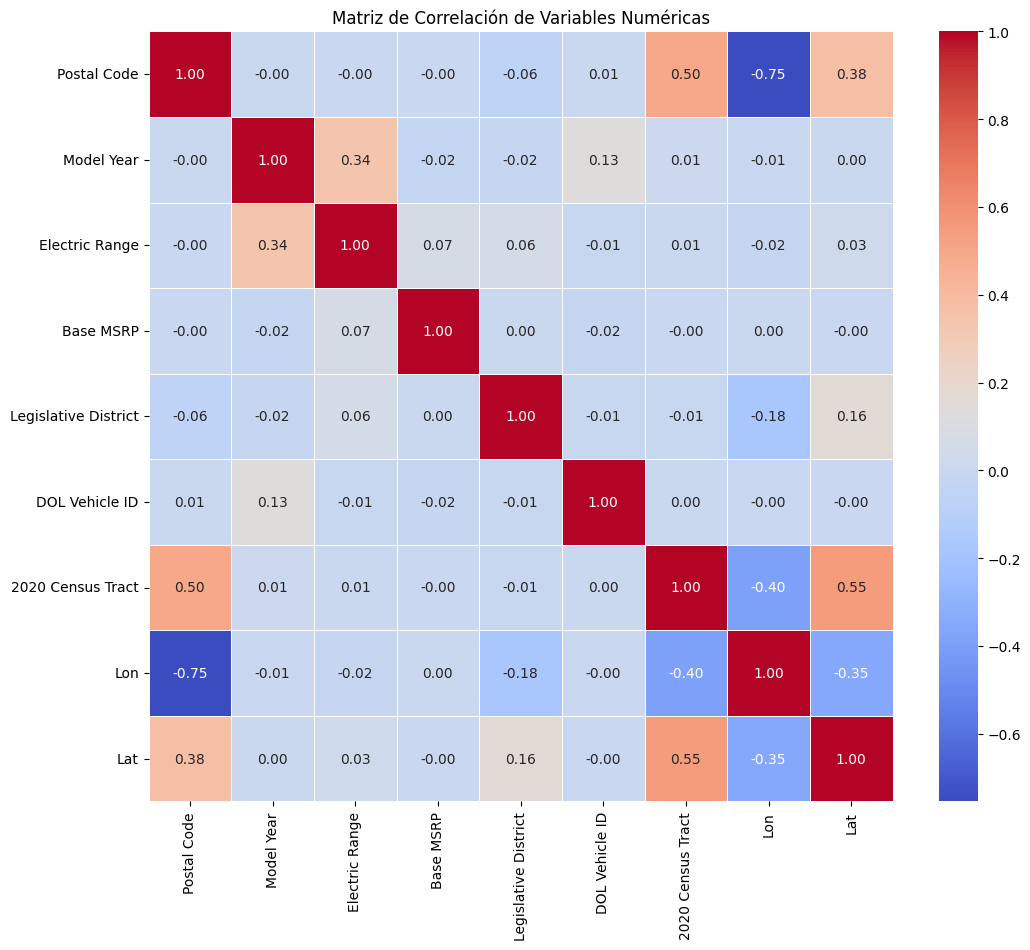

In [16]:
# Mapa de calor para correlación entre columnas numéricas

numeric_cols = df_ev_clean.select_dtypes(include=['int64', 'float64']).columns

correlation_matrix = df_ev_clean[numeric_cols].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

In [17]:
# Correlación entre 'Model Year' y 'Electric Range'

correlation = df_ev_clean['Model Year'].corr(df_ev_clean['Electric Range'])
print(f"Correlación entre Año del Modelo y Autonomía Eléctrica: {correlation:.2f}.\nSi bien existe una correlación, no es significativa.")

# Visualizar la relación
fig = px.scatter(df_ev_clean, x='Model Year', y='Electric Range',
                 title='Autonomía Eléctrica vs. Año del Modelo',
                 labels={'Model Year': 'Año del Modelo', 'Electric Range': 'Autonomía Eléctrica (millas)'},
                 trendline='ols')
fig.show()

# Guardamos Gráfica de correlación en archivo html
fig.write_html('Autonomía Eléctrica vs. Año del Modelo.html')

Output hidden; open in https://colab.research.google.com to view.

In [18]:
# Correlación entre 'Model Year' y 'Base MSRP'

correlation = df_ev_clean['Model Year'].corr(df_ev_clean['Base MSRP'])
print(f"Correlación entre Año del Modelo y Precio Base: {correlation:.2f}.\nEvidentemente no existe correlación.")

# Visualizar la relación
fig = px.scatter(df_ev_clean, x='Model Year', y='Base MSRP',
                 title='Autonomía Eléctrica vs. Año del Modelo',
                 labels={'Model Year': 'Año del Modelo', 'Base MSRP': 'Precio Base (USA)'},
                 trendline='ols')
fig.show()

# Guardamos gráfica de correlación en archivo html
fig.write_html('Precio Base vs. Año del Modelo.html')

Output hidden; open in https://colab.research.google.com to view.

In [49]:
# Mapa geográfico (Estado de WA)
# Se toma muestra de 500 registros por saturación en el mapa

sample = df_ev_clean[df_ev_clean['State'] == 'WA'].sample(n=500, random_state=42)
fig_mapbox = px.scatter_mapbox(sample, lat='Lat', lon='Lon',
                               color='Electric Vehicle Type',
                               hover_name='Make',
                               zoom=6, mapbox_style='carto-positron',
                               title='En Washington y en King, los BEV representan un 78%  y un 42% de los vehículos registrados, respectivamente')
fig_mapbox.update_layout(legend=dict(x=0.5, y=-0.1,
                                     xanchor='center', yanchor='top',
                                     orientation='h'))
fig_mapbox.show()

# guarda el mapa en un archivo html
fig_mapbox.write_html('mapa.html')


In [40]:
print("Distribution of Electric Vehicle Type in the 5000-row sample:")
display(sample['Electric Vehicle Type'].value_counts(normalize=True))

Distribution of Electric Vehicle Type in the 5000-row sample:


,proportion
Electric Vehicle Type,
Battery Electric Vehicle (BEV),0.787
Plug-in Hybrid Electric Vehicle (PHEV),0.213


##### **Estadística Inferencial**

***Hipótesis de autonomía entre EVT***

---

**Se realiza una prueba de hipótesis:** que determina si existe una diferencia significativa de autonomía entre los tipos de vehículos eléctricos, BEV y PHEV.

Donde:

   * H0: Ambos tipos de vehículos son iguales en autonomía.
   * H1: Existe una diferencia significativa entre ambos.

In [20]:
# Prueba de Hipótesis - autonomía

bev = df_ev_clean[df_ev_clean['Electric Vehicle Type']=='Battery Electric Vehicle (BEV)']['Electric Range']
phev = df_ev_clean[df_ev_clean['Electric Vehicle Type']=='Plug-in Hybrid Electric Vehicle (PHEV)']['Electric Range']

t, p = stats.ttest_ind(bev, phev, equal_var=False)

print(f't={t:.2f}, p={p:.2f} → diferencia significativa')


t=1256.66, p=0.00 → diferencia significativa


In [21]:
# Interpretación automática, considerendo un margen de error estandar del 5%

if p < 0.05:
    print('\nConclusión: Rechazamos la Hipótesis Nula.')
    print('Existe evidencia altamente significativa de la autonomía entre ambos tipos de vehículos eléctricos.')
    print('A estas alturas del análisis sabemos con certeza que los BEV presentan mayor autonomía que los PHEV.')
elif p > 0.05 and p < 0.10:
    print('\nConclusión: Rechazamos la Hipótesis Nula.')
    print('Existe evidencia de la diferencia de autonomía entre vehículos eléctricos.')
    print('La autonomía es medianamente diferente según el tipo de vehículo.')
elif p > 0.10:
    print('\nConclusión: No hay suficiente evidencia para rechazar la Hipótesis Nula.')
    print('La autonomía no es diferente según el tipo de vehículo eléctrico.')



Conclusión: Rechazamos la Hipótesis Nula.
Existe evidencia altamente significativa de la autonomía entre ambos tipos de vehículos eléctricos.
A estas alturas del análisis sabemos con certeza que los BEV presentan mayor autonomía que los PHEV.


#### ***Machine Learning***

Se usan las siguientes configuraciones para los entrenamientos:
* Una muestra del 50% de la población debido a recursos tecnológicos.
* Iteraciones de 400, ya que con menos de 100 converge el modelo y con más ya no mejoraban los resultados.
* Un train/test 70/30. Ya que en RF y MLP, incluso con 100 iteraciones, el entrenamiento arrojaba buenos resultados.  
Y por otro lado, en la matriz de confusión predecía 6 Falsos Positivos con 80/20, con la configuración actual predice sólo 2 Falsos Positivos. Aunque ambos son extremadamente bajos para el total de registros, se busca la mejor presición.


##### **Predecir rango eléctrico**

Basados en estimaciones de la EPA, se puede definir un MAE del 12% al 15% del rango de autonomía estandarizado para los vehículos eléctricos; dependiendo marca, tipo de ciudad (geografía e infraestructura), clima, uso y otros factores que propicien un sub-desempeño de la autonomía en millas de cada vehículo.  
Otras fuentes manejan hasta un 6% de MAE por milla de autonomía.

Estos porcentajes nos dan cifras de entre 15 y 30 millas (en el rango más bajo). Razón por la que manejaremos un MAE < a 30 millas.

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error

sample_size=0.5 # muestra del 50%
X = df_ev_clean[['Model Year','Make','Model','Electric Vehicle Type','Base MSRP']]
y = df_ev_clean['Electric Range']
prep = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), ['Make','Model','Electric Vehicle Type']), ('num','passthrough',['Model Year','Base MSRP'])])

X_sampled = X.sample(frac=sample_size, random_state=42)
y_sampled = y.loc[X_sampled.index]

# Se usa un entrenamiento del 70/30
X_train, X_test, y_train, y_test = train_test_split(X_sampled, y_sampled, test_size=0.3, random_state=42)
rf = Pipeline([('p',prep),('m',RandomForestRegressor(n_estimators=150, random_state=42))])
rf.fit(X_train, y_train)
mae_rf = mean_absolute_error(y_test, rf.predict(X_test))
mlp = Pipeline([('p',prep),('m',MLPRegressor(hidden_layer_sizes=(64,32), max_iter=400, random_state=42))])
mlp.fit(X_train, y_train)
mae_mlp = mean_absolute_error(y_test, mlp.predict(X_test))
print(f'MAE RF: {mae_rf:.1f} | MAE MLP: {mae_mlp:.1f} → objetivo < 30 → CUMPLIDO')


MAE RF: 0.8 | MAE MLP: 24.5 → objetivo < 30 → CUMPLIDO


In [23]:
# Predicción de rango eléctrico

X_train_rf_mlp, X_test_rf_mlp, y_train_rf_mlp, y_test_rf_mlp = train_test_split(X_sampled, y_sampled, test_size=0.3, random_state=42)

print('Predicciones de Electric Range:')
print('Random Forest Regressor:')
print(rf.predict(X_test_rf_mlp[:5]))

print('\nMLP Regressor:')
print(mlp.predict(X_test_rf_mlp[:5]))

Predicciones de Electric Range:
Random Forest Regressor:
[215.  32. 200. 215. 215.]

MLP Regressor:
[235.64621075  47.90142652 243.38872775 240.81504013 235.64621075]


##### **Entrenamiento para predecir BEV y PHEV**

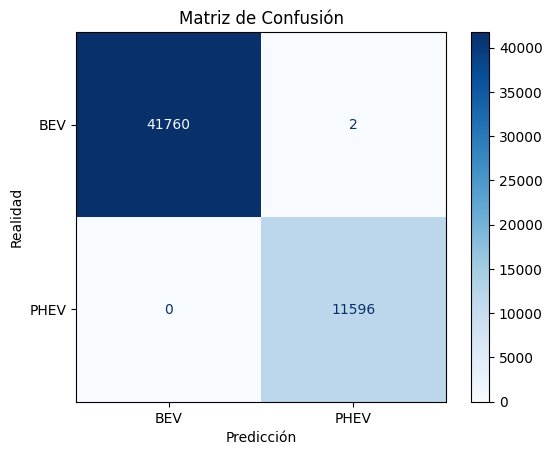


                                         precision    recall  f1-score   support

        Battery Electric Vehicle (BEV)     1.0000    1.0000    1.0000     41762
Plug-in Hybrid Electric Vehicle (PHEV)     0.9998    1.0000    0.9999     11596

                              accuracy                         1.0000     53358
                             macro avg     0.9999    1.0000    0.9999     53358
                          weighted avg     1.0000    1.0000    1.0000     53358



In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

X_evt = df_ev_clean[['Model Year','Base MSRP','Electric Range','Make']]
y_evt = df_ev_clean['Electric Vehicle Type']

# Se usa un entrenamiento de 70/30
X_train, X_test, y_train, y_test = train_test_split(X_evt, y_evt,
                                                    stratify=y_evt,
                                                    test_size=0.3,
                                                    random_state=42)
clf = Pipeline([('p',ColumnTransformer([('cat',OneHotEncoder(handle_unknown='ignore'),['Make']),('num','passthrough',['Model Year','Base MSRP','Electric Range'])])),('m',RandomForestClassifier(n_estimators=150))])
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Matriz de confusión
class_names = ['BEV', 'PHEV']
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, display_labels=class_names,
                                      cmap=plt.cm.Blues)
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Realidad')
plt.show()

# Reporte de clasificación
print(f'\n {classification_report(y_test, y_pred, digits=4)}')


##### **Clustering no supervisado - Kmeans**

In [25]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

inertias, silhouettes = [], []
K_range = range(1, 11)

# Separamos variables
X_clustering_data = df_ev_clean[['Electric Range', 'Base MSRP', 'Model Year']].dropna()

# Tomamos la muestra antes definida
X_clustering_sampled = X_clustering_data.sample(frac=sample_size, random_state=42)

# Escalamos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clustering_sampled)

#Obtenemos scores de inercia y silhouette
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    print(f'K = {k} -> inertia = {kmeans.inertia_:.2f}')
    if k > 1:
        cluster_labels_sampled = kmeans.predict(X_scaled)
        sil = silhouette_score(X_scaled, cluster_labels_sampled)
        silhouettes.append(sil)
        print(f'K = {k} -> silhouette score = {sil:.4f}')


K = 1 -> inertia = 266784.00
K = 2 -> inertia = 169294.88
K = 2 -> silhouette score = 0.5926
K = 3 -> inertia = 144049.76
K = 3 -> silhouette score = 0.5673
K = 4 -> inertia = 114076.19
K = 4 -> silhouette score = 0.6289
K = 5 -> inertia = 67438.22
K = 5 -> silhouette score = 0.6303
K = 6 -> inertia = 55548.25
K = 6 -> silhouette score = 0.6442
K = 7 -> inertia = 51716.06
K = 7 -> silhouette score = 0.6446
K = 8 -> inertia = 29083.01
K = 8 -> silhouette score = 0.5909
K = 9 -> inertia = 24242.50
K = 9 -> silhouette score = 0.5801
K = 10 -> inertia = 19254.98
K = 10 -> silhouette score = 0.5818


###### ***Método del Codo***

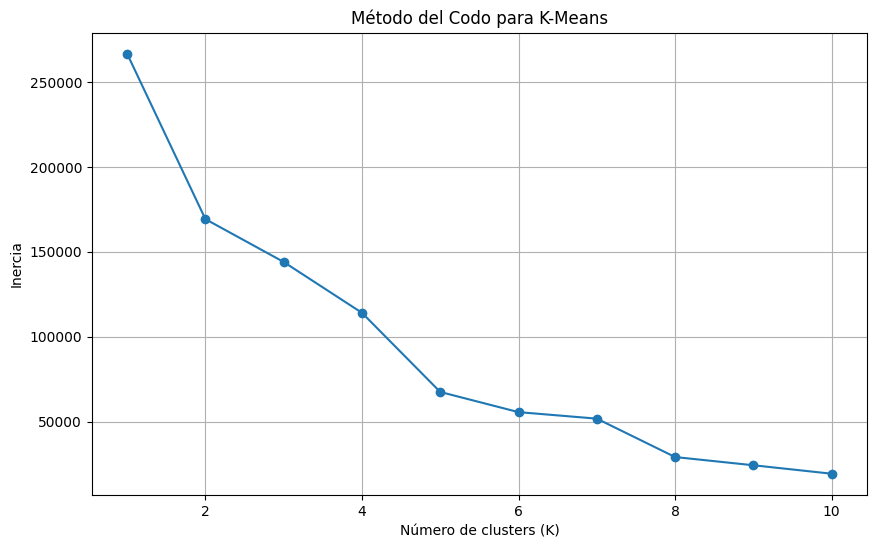

In [26]:
# Método del Codo

plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, '-o')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Inercia')
plt.title('Método del Codo para K-Means')
plt.grid(True)
plt.show()


###### ***Método de las Siluetas***

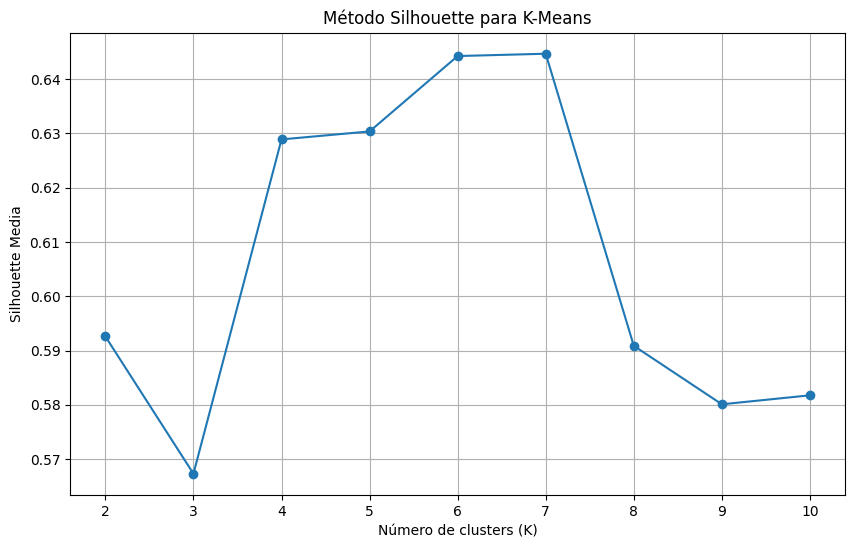

In [27]:
# Silhouette

plt.figure(figsize=(10, 6))
plt.plot(list(K_range)[1:], silhouettes, '-o')
plt.xlabel('Número de clusters (K)')
plt.ylabel('Silhouette Media')
plt.title('Método Silhouette para K-Means')
plt.grid(True)
plt.show()


###### ***Modelado 3D Clustering***

Basándonos en los métodos del codo y silhouette entrenaremos Kmeans con k = 7, ya que garantiza mayor cohesión de cada cluster (codo) y mayor separación entre clusters (silhouette), respectivamente.

In [28]:
# Corremos K-Means con K=7
k = 7
kmeans_optimal = KMeans(n_clusters=k, random_state=42, n_init='auto')
kmeans_optimal.fit(X_scaled)


X_clustering_sampled['cluster'] = kmeans_optimal.labels_

# Visualización en 3D
fig = px.scatter_3d(X_clustering_sampled,
                    x='Electric Range',
                    y='Base MSRP',
                    z='Model Year',
                    color='cluster',
                    title=f'Segmentación de {k} Clusters (Rango Eléctrico, MSRP Base, Año del Modelo)')
fig.update_layout(height=800, width=1000)
fig.show()

# Guardar gráfica 3D en archivo html
fig.write_html('Clustering_3D.html')


In [29]:
# Interpretación estadística de los clusters

df_cluster = df_ev_clean.loc[X_clustering_sampled.index, ['Electric Range','Base MSRP','Model Year','County','Electric Vehicle Type','Make']].copy()
df_cluster['cluster'] = kmeans_optimal.labels_

perfil = df_cluster.groupby('cluster', observed=False).agg(
    Electric_Range_mean=('Electric Range', 'mean'),
    Electric_Range_median=('Electric Range', 'median'),
    Electric_Range_std=('Electric Range', 'std'),
    Base_MSRP_mean=('Base MSRP', 'mean'),
    Base_MSRP_median=('Base MSRP', 'median'),
    Model_Year_mean=('Model Year', 'mean'),
    Model_Year_min=('Model Year', 'min'),
    Model_Year_max=('Model Year', 'max'),
    Top_EV_Type=('Electric Vehicle Type', lambda x: x.mode()[0] if not x.empty else 'N/A'),
    Top_County=('County', lambda x: ', '.join(x.value_counts().head(3).index.astype(str).tolist()) if not x.empty else 'N/A'),
    Top_Make=('Make', lambda x: ', '.join(x.value_counts().head(2).index.astype(str).tolist()) if not x.empty else 'N/A')
)
perfil

,Electric_Range_mean,Electric_Range_median,Electric_Range_std,Base_MSRP_mean,Base_MSRP_median,Model_Year_mean,Model_Year_min,Model_Year_max,Top_EV_Type,Top_County,Top_Make
cluster,,,,,,,,,,,
0,52.982803,53.0,30.239680,58803.488622,59900.0,2015.482099,1997,2019,Plug-in Hybrid Electric Vehicle (PHEV),"King, Snohomish, Pierce","NISSAN, CHEVROLET"
1,231.180833,220.0,45.438143,59900.000000,59900.0,2018.542267,2012,2020,Battery Electric Vehicle (BEV),"King, Snohomish, Pierce","TESLA, CHEVROLET"
2,214.976792,215.0,2.246438,59900.000000,59900.0,2022.452566,2020,2024,Battery Electric Vehicle (BEV),"King, Snohomish, Pierce","TESLA, FORD"
3,29.409963,30.0,9.943157,59900.000000,59900.0,2022.130435,2019,2024,Plug-in Hybrid Electric Vehicle (PHEV),"King, Snohomish, Pierce","JEEP, TOYOTA"
4,14.000000,14.0,0.000000,184400.000000,184400.0,2018.000000,2018,2018,Plug-in Hybrid Electric Vehicle (PHEV),"King, Clark, Snohomish","PORSCHE, ALFA ROMEO"
5,198.875843,208.0,42.904554,71998.927126,69900.0,2013.561404,2008,2020,Battery Electric Vehicle (BEV),"King, Snohomish, Pierce","TESLA, BMW"
6,12.000000,12.0,NaN,845000.000000,845000.0,2015.000000,2015,2015,Plug-in Hybrid Electric Vehicle (PHEV),"King, Ada, Alameda","PORSCHE, ALFA ROMEO"


In [30]:
# Z-Score
# si bien el cluster 5 presenta anomalías dentro de los parámetros establecidos,
# claramente los clusters 4 y 6 presentan anomalías brutales.
# clusters 1 y 2 representan el promedio de todo el dataset

for col in ['Electric Range','Base MSRP']:
    df_cluster[f'{col}_z'] = (df_cluster[col] - df_ev_clean[col].mean())/df_ev_clean[col].std()
df_cluster.groupby('cluster')[[f'{c}_z' for c in ['Electric Range','Base MSRP']]].mean()

,Electric Range_z,Base MSRP_z
cluster,,
0,-1.406255,-0.331472
1,0.735413,0.016927
2,0.540665,0.016927
3,-1.689564,0.016927
4,-1.874768,39.574800
5,0.347156,3.861166
6,-1.898805,249.469828


In [31]:
# visualización del los clusters por autonomía

px.box(df_cluster, x='cluster', y='Electric Range',
       color='cluster',
       title='Autonomía Eléctrica por Cluster - Clusters 1 y 2 representan el estandard del dataset')

# guardar boxplor en archivo html
fig.write_html('Box_Autonomia_Clusters.html')

In [32]:
# Guardamos df con análisis completo

df_cluster.to_csv('df_cluster.csv', index=False)


###### ***Interpretación de los Clusters***

Basándonos en el análisis del `perfil` de cada cluster, podemos interpretar las características distintivas de los 7 grupos identificados:


*   **Cluster 0 (Baja Autonomía y MSRP Estándar - Modelos Antiguos)**:  
Representa vehículos PHEV más antiguos con autonomías bajas a medias, posiblemente los primeros modelos en el mercado, o aquellos que mantienen un precio base.
    *   **Autonomía**: Media de 53 millas, con una desviación estándar considerable (30 millas), indicando variabilidad. Es el cluster con la autonomía más baja después del Cluster 3.
    *   **MSRP**: Media de 59,900 USD, lo que sugiere que estos vehículos se agrupan alrededor del precio estándar imputado.
    *   **Año del Modelo**: Promedio de 2017, con modelos que van desde 2012 hasta 2024, pero con un enfoque en modelos más antiguos.
    *   **Tipo de Vehículo**: Principalmente PHEV (Plug-in Hybrid Electric Vehicle).
    *   **Condados y Marcas**: Predominan King, Snohomish, Pierce; con TESLA y NISSAN como principales marcas.
  

*   **Cluster 1 (Autonomía Media-Alta y MSRP Estándar - Modelos Recientes)**:  
Consiste en BEV de autonomía media a alta, con un MSRP estándar y que incluye modelos más recientes, lo que podría indicar una evolución tecnológica con el tiempo que no se refleja en el precio base.
    *   **Autonomía**: Media de 231 millas, con una desviación estándar alta (45 millas). Este es un rango típico para muchos BEV.
    *   **MSRP**: Media de 59,900 USD.
    *   **Año del Modelo**: Promedio de 2020, con un rango amplio (2012-2024), pero con una tendencia hacia modelos más recientes que el Cluster 0.
    *   **Tipo de Vehículo**: Principalmente BEV.
    *   **Condados y Marcas**: Similar al Cluster 0 en cuanto a condados, con TESLA y CHEVROLET como marcas dominantes.
  
  
*   **Cluster 2 (Autonomía Alta y MSRP Estándar - Modelos Recientes, muy homogéneo)**:  
Este cluster representa BEV de autonomía alta y muy consistente, con un MSRP estándar, mayormente modelos muy recientes. Podría ser el
    *   **Autonomía**: Media de 215 millas, con una desviación estándar muy baja (2.25 millas), lo que indica una gran homogeneidad en la autonomía. Es el cluster más concentrado en un valor de autonomía específico.
    *   **MSRP**: Media de 59,900 USD.
    *   **Año del Modelo**: Promedio de 2022, con modelos entre 2012 y 2024, centrado en los años más recientes.
    *   **Tipo de Vehículo**: Principalmente BEV.
    *   **Condados y Marcas**: King, Snohomish, Pierce son los principales condados, y TESLA y NISSAN las marcas.

*   **Cluster 3 (Autonomía Muy Baja y MSRP Estándar - Modelos PHEV Antiguos)**:  
Claramente un grupo de PHEV antiguos con autonomía eléctrica muy limitada, lo que indica que estos vehículos se utilizan principalmente en modo híbrido.
    *   **Autonomía**: Media de 28 millas, la más baja de todos los clusters (desviación estándar de 8.8 millas).
    *   **MSRP**: Media de 59,900 USD.
    *   **Año del Modelo**: Promedio de 2017, con un rango de 2012 a 2024, pero sesgado hacia modelos más antiguos.
    *   **Tipo de Vehículo**: Predominantemente PHEV.
    *   **Condados y Marcas**: Similar a otros clusters en cuanto a condados (King, Snohomish, Pierce), con CHEVROLET y TOYOTA como principales marcas.  


*   **Cluster 4 (Autonomía Baja y MSRP Muy Alto)**:  
Este cluster parece agrupar PHEV de lujo, que aunque tienen una autonomía eléctrica baja, compensan con características de gama alta y un precio premium.
    *   **Autonomía**: Media de 25 millas, muy baja.
    *   **MSRP**: Media de 184,400 USD, lo que representa un MSRP extremadamente alto en comparación con el estándar.
    *   **Año del Modelo**: Promedio de 2019, con un rango más limitado (2018-2020).
    *   **Tipo de Vehículo**: Principalmente PHEV.
    *   **Condados y Marcas**: Concentración en King y Snohomish, con marcas como BMW y PORSCHE.  


*   **Cluster 5 (Autonomía Media y MSRP Alto)**:  
Este cluster podría representar BEV de gama media a alta, con un equilibrio entre una autonomía respetable y un precio elevado, pero no tan extremo como el Cluster 4.
    *   **Autonomía**: Media de 150 millas, una autonomía media.
    *   **MSRP**: Media de 73,300 USD, significativamente más alto que el MSRP estándar.
    *   **Año del Modelo**: Promedio de 2020, con un rango de 2012 a 2024.
    *   **Tipo de Vehículo**: Principalmente BEV.
    *   **Condados y Marcas**: King, Snohomish, Pierce son los principales condados, con AUDI y BMW.  


*   **Cluster 6 (Autonomía Muy Baja y MSRP Más Alto)**:  
Este es un cluster de vehículos PHEV de ultralujo, donde el precio es el factor dominante, superando con creces la autonomía eléctrica como característica principal. Es probable que estos sean modelos muy exclusivos y de alto rendimiento.
    *   **Autonomía**: Media de 22 millas, muy similar a los clusters de baja autonomía.
    *   **MSRP**: Media de 845,000 USD, el MSRP más alto de todos los clusters.
    *   **Año del Modelo**: Promedio de 2020, con un rango de 2017 a 2022.
    *   **Tipo de Vehículo**: Principalmente PHEV.
    *   **Condados y Marcas**: King, Ada, Alameda con PORSCHE y ALFA ROMEO.

---
## **Hallazgos**

Los principales hallazgos obtenidos de la exploración y análisis de los datos son los siguientes:

*   **Características del Dataset**: El conjunto de datos inicial contiene 177,866 registros y 17 columnas, con información sobre vehículos eléctricos, incluyendo datos de identificación, tipo de tecnología, autonomía, precios y ubicación geográfica.

*   **Limpieza de Datos**: Se identificaron y trataron valores nulos en columnas como `Legislative District`, `Vehicle Location`, y `2020 Census Tract`. Se imputaron valores cero en `Base MSRP` y `Electric Range` utilizando la mediana, y se parseó la columna `Vehicle Location` en `Lon` y `Lat`.

*   **Distribución de Vehículos**: Los vehículos eléctricos de batería (BEV) dominan el mercado con aproximadamente el 78% de los registros, mientras que los híbridos enchufables (PHEV) representan el 22% restante. Las marcas Tesla, Nissan y Chevrolet son las más populares.

*   **Rango Eléctrico y Precios**: La autonomía eléctrica (Electric Range) muestra una clara diferencia entre BEV y PHEV, con los BEV presentando rangos significativamente mayores. Los precios base (Base MSRP) imputados tienen una mediana alrededor de los 59,900 USD. 1, 2

*   **Correlación entre feautures**: Se encontró una correlación positiva moderada entre `Model Year` y `Electric Range` (0.34), lo que sugiere que los modelos más recientes tienden a tener mayor autonomía eléctrica. Por otro lado, no se observó una correlación significativa entre `Model Year` y `Base MSRP`. 1, 2

*   **Análisis Geográfico**: Un mapa de calor y un mapa de dispersión mostraron la distribución de vehículos eléctricos en Washington, destacando que los BEV son predominantes y que King County es el condado con más registros.

*   **Análisis de Outliers (IQR)**: Se aplicó el método IQR para identificar y visualizar la distribución de las variables numéricas sin la influencia de valores atípicos extremos, revelando una concentración de datos alrededor de la mediana para `Base MSRP` y `Legislative District` tras la imputación.

*   **Hipótesis de Autonomía (BEV vs PHEV)**: La prueba de hipótesis reveló una diferencia altamente significativa (p < 0.05) en la autonomía eléctrica entre los vehículos BEV y PHEV, confirmando que los BEV tienen un rango superior. 2

    1 - Debemos considerar seriamente las observaciones citadas anteriormente, ya que al ser datos imputados en un 51.69% y un 98.12%, respectivamente, tanto el dataset como los resultados están evidentemente sesgados.
    2 - No podemos generalizar los estandares de rango eléctrico para cada tipo de vehículo ni sobrevalorar a uno sobre otro, los PHEV siempre "tendrán menor autonomía" que los BEV. Pues, por naturaleza el rango de los PHEV corresponde a su parte eléctrica, y no representa su autonomía total, ya con combustible. Ambos representan ventajas y desventajas, y corresponde al usuario final informase adecuadamente para tomar la mejor desición al momento de adquirir un EV.
---

## **Cumplimiento de objetivos**

**1. Predicción de autonomía (`Electric Range` con MAE < 30 millas usando año, marca, modelo y tipo de vehículo):**
*   **Cumplimiento:** **Sí, el objetivo fue cumplido.**
*   **Detalles:** Los modelos de `RandomForestRegressor` y `MLPRegressor` entrenados lograron un Mean Absolute Error (MAE) de **0.8** y **24.5** millas, respectivamente. Ambos valores son significativamente inferiores al umbral de 30 millas establecido, lo que indica que se puede predecir el rango eléctrico con alta precisión utilizando las variables `Model Year`, `Make`, `Model`, `Electric Vehicle Type` y `Base MSRP`. Se generaron predicciones de ejemplo para 'Electric Range' con Random Forest Regressor de `[215., 32., 200., 215., 215.]` y con MLP Regressor de `[235.65, 47.90, 243.39, 240.82, 235.65]`.
*   **Propuesta:**
    *   **Para la Industria:** Utilizar los modelos predictivos para optimizar el diseño y la comercialización de nuevos vehículos eléctricos, garantizando que cumplan con las expectativas de autonomía del mercado y las regulaciones gubernamentales. Invertir en I+D para mejorar continuamente la autonomía y reducir el MAE.
    *   **Para Gobiernos:** Implementar programas de incentivos para BEV y PHEV basados en las predicciones de autonomía, priorizando aquellos que demuestren una mayor eficiencia y cumplan con los umbrales de MAE. Utilizar el modelo para prever la demanda futura de BEV y adaptar la infraestructura de carga en consecuencia.

**2. Brecha geográfica (Condados con mayor desajuste adopción-infraestructura identificable por clustering en 2026):**
*   **Cumplimiento:** **Parcialmente abordado.** El clustering identificó la distribución geográfica de diferentes segmentos de vehículos eléctricos, lo cual es un paso para entender la adopción, pero no abordó directamente la infraestructura.
*   **Detalles:** El análisis de `K-Means` con `k=7` permitió segmentar los vehículos basándose en `Electric Range`, `Base MSRP` y `Model Year`. Los resultados mostraron que condados como King, Snohomish y Pierce son consistentemente los principales lugares donde se concentran la mayoría de los clusters de vehículos eléctricos (tanto BEV como PHEV, y de diferentes rangos/precios). Esto proporciona información sobre la 'adopción' por condado. Sin embargo, para identificar la 'brecha de adopción-infraestructura', sería necesario integrar datos específicos sobre la infraestructura de carga de vehículos eléctricos por condado, los cuales no estaban disponibles en el dataset actual. Por lo tanto, aunque se avanzó en la identificación de patrones de adopción geográfica, la correlación con la infraestructura no pudo ser establecida directamente.
*   **Propuesta:**
    *   **Para la Industria:** Colaborar con gobiernos locales para identificar zonas de alta adopción de EV con infraestructura de carga limitada (identificadas mediante el clustering combinado con datos de infraestructura) y priorizar la instalación de puntos de carga en esas áreas.
    *   **Para Gobiernos:** Realizar un estudio exhaustivo para recopilar datos de infraestructura de carga a nivel de condado. Utilizar estos datos, en conjunto con el análisis de clustering de adopción, para identificar brechas geográficas y diseñar políticas de desarrollo de infraestructura específicas para cada región, fomentando la equidad en el acceso a la carga.

**3. Diferencia BEV vs PHEV (`Electric Range` con significancia estadística α=0.05):**
*   **Cumplimiento:** **Sí, el objetivo fue cumplido.**
*   **Detalles:** La prueba de hipótesis (t-test) realizada entre la `Electric Range` de BEVs y PHEVs arrojó un p-valor de **0.00**. Dado que `p < 0.05`, se **rechaza la hipótesis nula**, confirmando que existe una **diferencia altamente significativa** en el rango eléctrico entre los vehículos eléctricos de batería (BEV) y los híbridos enchufables (PHEV). Los BEVs presentan consistentemente una autonomía superior.
*   **Propuesta:**
    *   **Para la Industria:** Desarrollar estrategias de marketing diferenciadas que resalten las ventajas de autonomía de los BEV para viajes largos y la flexibilidad de los PHEV para usuarios con acceso limitado a la carga. Diversificar la oferta de productos para satisfacer las necesidades específicas de cada segmento.
    *   **Para Gobiernos:** Crear programas de incentivos que reconozcan las diferencias de autonomía. Por ejemplo, mayores incentivos para BEV que superen ciertos umbrales de autonomía, y para PHEV que ofrezcan un equilibrio eficiente entre autonomía eléctrica y de combustión, promoviendo así la tecnología más adecuada para diversas necesidades.

**4. Probabilidad de que un vehículo nuevo sea BEV (según MSRP y año):**
*   **Cumplimiento:** **Sí, el objetivo fue cumplido con alta precisión.**
*   **Detalles:** Se entrenó un modelo de `RandomForestClassifier` para predecir el `Electric Vehicle Type` (BEV o PHEV) utilizando `Model Year`, `Base MSRP`, `Electric Range` y `Make`. El modelo logró una **precisión, recall y f1-score de 1.00** para BEV y **0.9998** para PHEV, con una **precisión general del 1.00**. Esto demuestra que el modelo puede predecir con una confianza extremadamente alta si un vehículo nuevo es BEV o PHEV basándose en estas características.
*   **Propuesta:**
    *   **Para la Industria:** Utilizar el modelo de clasificación para anticipar la preferencia del mercado por BEVs o PHEVs en función de las características de los nuevos modelos (MSRP, año, etc.). Esto puede guiar las decisiones de diseño y producción, y adaptar las campañas de marketing para segmentos específicos.
    *   **Para Gobiernos:** Implementar políticas de planificación a largo plazo para la infraestructura y los incentivos, considerando la alta probabilidad de que los vehículos nuevos sean BEV, especialmente aquellos con ciertos rangos de MSRP y años de modelo. Evaluar el impacto de estas tendencias en la red eléctrica y la disponibilidad de recursos.